<img src="../Pierian-Data-Logo.PNG">
<br>
<strong><center>Copyright 2019. Created by Jose Marcial Portilla.</center></strong>

# CNN Exercises
For these exercises we'll work with the <a href='https://www.kaggle.com/zalando-research/fashionmnist'>Fashion-MNIST</a> dataset, also available through <a href='https://pytorch.org/docs/stable/torchvision/index.html'><tt><strong>torchvision</strong></tt></a>. Like MNIST, this dataset consists of a training set of 60,000 examples and a test set of 10,000 examples. Each example is a 28x28 grayscale image, associated with a label from 10 classes:
0. T-shirt/top
1. Trouser
2. Pullover
3. Dress
4. Coat
5. Sandal
6. Shirt
7. Sneaker
8. Bag
9. Ankle boot

<div class="alert alert-danger" style="margin: 10px"><strong>IMPORTANT NOTE!</strong> Make sure you don't run the cells directly above the example output shown, <br>otherwise you will end up writing over the example output!</div>

## Perform standard imports, load the Fashion-MNIST dataset
Run the cell below to load the libraries needed for this exercise and the Fashion-MNIST dataset.<br>
PyTorch makes the Fashion-MNIST dataset available through <a href='https://pytorch.org/docs/stable/torchvision/datasets.html#fashion-mnist'><tt><strong>torchvision</strong></tt></a>. The first time it's called, the dataset will be downloaded onto your computer to the path specified. From that point, torchvision will always look for a local copy before attempting another download.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

In [4]:
!nvidia-smi

Wed Jun 17 23:53:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [20]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

%config InlineBackend.figure_format = 'svg'

In [3]:
transform = transforms.ToTensor()

train_data = datasets.FashionMNIST(root='../Data', train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST(root='../Data', train=False, download=True, transform=transform)

class_names = ['T-shirt','Trouser','Sweater','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Boot']

100%|██████████| 26.4M/26.4M [00:01<00:00, 14.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 214kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.95MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.6MB/s]


In [6]:
train_data

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: ../Data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [7]:
test_data

Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: ../Data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [8]:
len(train_data) , len(test_data)

(60000, 10000)

## 1. Create data loaders
Use DataLoader to create a <tt>train_loader</tt> and a <tt>test_loader</tt>. Batch sizes should be 10 for both.

In [ ]:
# CODE HERE
torch.manual_seed(101)
train_loader = DataLoader(train_data , batch_size = 10 , shuffle = True )
test_loader = DataLoader(test_data , batch_size = 10 , shuffle = False)

In [10]:
len(train_loader) , len(test_loader)

(6000, 1000)

In [12]:
for images , labels in train_loader:
    break

In [15]:
images.shape
# (10, 1, 28, 28) : batch_size , channel , height , width

torch.Size([10, 1, 28, 28])

In [16]:
labels.shape

torch.Size([10])

## 2. Examine a batch of images
Use DataLoader, <tt>make_grid</tt> and matplotlib to display the first batch of 10 images.<br>
OPTIONAL: display the labels as well

In [28]:
labels

tensor([0, 8, 9, 3, 9, 7, 6, 7, 1, 0])

In [36]:
[class_names[i] for i in labels.numpy()]

['T-shirt',
 'Bag',
 'Boot',
 'Dress',
 'Boot',
 'Sneaker',
 'Shirt',
 'Sneaker',
 'Trouser',
 'T-shirt']

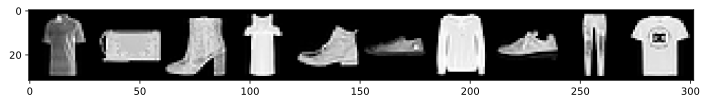

In [50]:
plt.figure(figsize=(12,4))
im = make_grid(images , nrow =10)
plt.imshow(im.numpy().transpose(1,2,0))
plt.show()

Labels :[    0     8     9     3     9     7     6     7     1     0]
Class: T-shirt Bag Boot Dress Boot Sneaker Shirt Sneaker Trouser T-shirt


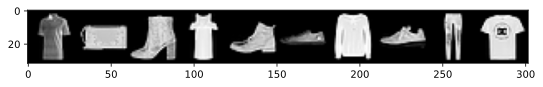

In [52]:
np.set_printoptions(formatter = dict(int = lambda x : f'{x:5}'))
im = make_grid(images , nrow =10)
plt.figure(figsize=(9,4))

print(f"Labels :{labels.numpy()}")
#print(f"Class: {[class_names[i] : for i in labels.numpy()]}")
print(f"Class: {' '.join([class_names[i] for i in labels.numpy()])}")

plt.imshow(im.numpy().transpose(1,2,0))
plt.show()

## Downsampling
<h3>3. If a 28x28 image is passed through a Convolutional layer using a 5x5 filter, a step size of 1, and no padding, what is the resulting matrix size?</h3>

In [56]:
(28-(5-1))/1

24.0

In [57]:
conv = nn.Conv2d(1, 1, 5, 1)
for x,labels in train_loader:
    print('Orig size:',x.shape)
    break
x = conv(x)
print('Down size:',x.shape)

Orig size: torch.Size([10, 1, 28, 28])
Down size: torch.Size([10, 1, 24, 24])


### 4. If the sample from question 3 is then passed through a 2x2 MaxPooling layer, what is the resulting matrix size?

In [93]:
((28-(5-1))/1)/2

12.0

In [58]:
x= F.max_pool2d(x, 2, 2)
print("Down size:", x.shape)

Down size: torch.Size([10, 1, 12, 12])


## CNN definition
### 5. Define a convolutional neural network
Define a CNN model that can be trained on the Fashion-MNIST dataset. The model should contain two convolutional layers, two pooling layers, and two fully connected layers. You can use any number of neurons per layer so long as the model takes in a 28x28 image and returns an output of 10. Portions of the definition have been filled in for convenience.

In [94]:
images.shape

torch.Size([10, 1, 28, 28])

In [95]:
conv1 = nn.Conv2d(in_channels = 1 , out_channels = 6  , kernel_size = 3 , stride = 1)
conv2 = nn.Conv2d(in_channels = 6 , out_channels = 16 , kernel_size = 3 , stride = 1)

In [99]:
first_layer = F.relu(conv1(images))
first_layer.shape

torch.Size([10, 6, 26, 26])

In [100]:
first_pool = F.max_pool2d(F.relu(first_layer) , kernel_size = 2 , stride = 2)
first_pool.shape

torch.Size([10, 6, 13, 13])

In [101]:
second_layer = F.relu(conv2(first_pool))
second_layer.shape

torch.Size([10, 16, 11, 11])

In [121]:
second_pool = F.max_pool2d(F.relu(second_layer) , kernel_size = 2 , stride = 2)
second_pool.shape[1:]

torch.Size([16, 5, 5])

In [123]:
torch.prod(torch.tensor(second_pool.shape[1:])).item()

400

In [110]:
second_pool.view(second_pool.shape[0] , -1).shape

torch.Size([10, 400])

In [ ]:
# CODE HERE
class ConvolutionalNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels = 1 , out_channels = 6  , kernel_size = 3 , stride = 1)
        self.conv2 = nn.Conv2d(in_channels = 6 , out_channels = 16 , kernel_size = 3 , stride = 1)
        self.fc1 = nn.Linear(in_features = 16*5*5 , out_features = 100)
        self.fc2 = nn.Linear(in_features = 100 , out_features = 10)
        

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x , kernel_size = 2 , stride = 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x , kernel_size = 2 , stride = 2)
        x = x.view(-1 , 16*5*5) #400 = 16*5*5
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return F.log_softmax(input = x , dim = 1)


torch.manual_seed(101)
model = ConvolutionalNetwork()
model = model.to(device)

In [177]:
model.parameters

<bound method Module.parameters of ConvolutionalNetwork(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=100, bias=True)
  (fc2): Linear(in_features=100, out_features=10, bias=True)
)>

## Trainable parameters

### 6. What is the total number of trainable parameters (weights & biases) in the model above?
Answers will vary depending on your model definition.

In [176]:
# CODE HERE
params = [p.numel() for p in model.parameters() if p.requires_grad]
for p in params:
    print(f"{p:>6,}")
print(f"______\n{sum([p.numel() for p in model.parameters()]): >6,}")

    54
     6
   864
    16
40,000
   100
 1,000
    10
______
42,050


### 7. Define loss function & optimizer
Define a loss function called "criterion" and an optimizer called "optimizer".<br>
You can use any functions you want, although we used Cross Entropy Loss and Adam (learning rate of 0.001) respectively.

In [ ]:
# CODE HERE
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters() , lr = 0.001)

model

ConvolutionalNetwork(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=100, bias=True)
  (fc2): Linear(in_features=100, out_features=10, bias=True)
)

### 8. Train the model
Don't worry about tracking loss values, displaying results, or validating the test set. Just train the model through 5 epochs. We'll evaluate the trained model in the next step.<br>
OPTIONAL: print something after each epoch to indicate training progress.

In [178]:
# CODE HERE
import time
start_time = time.time()

epochs = 5

train_losses = []
test_losses = []

train_correct = []
test_correct = []

for epoch in range(epochs):
    trn_corr = 0 
    tst_corr = 0


    for batch_idx_tr , (X_train , y_train) in enumerate(train_loader):
        batch_idx_tr += 1

        # Transform X_train & y_train to GPU:
        X_train = X_train.to(device)
        y_train = y_train.to(device)


        #Apply the model:
        y_pred = model(X_train)
        loss_train = criterion(y_pred , y_train)

        #Tally the number of correct predictions:
        train_predicted = torch.max(y_pred.data , dim = 1 , keepdim = True)[1]
        train_batch_corr = (train_predicted == y_train).sum()
        trn_corr += train_batch_corr

        #Update parameters
        optimizer.zero_grad()
        loss_train.backward()
        optimizer.step()

        if batch_idx_tr%1000 == 0:
            print(f"Epoch: {epoch} , Batch index: {batch_idx_tr} , loss: {loss_train.item()}")

    train_losses.append(loss_train.item())
    train_correct.append(trn_corr.item())

    # Run the testing batches:
    with torch.no_grad():
        for batch_idx_test , (X_test , y_test) in enumerate(test_loader):
            batch_idx_test += 1

            #  Transform X_test & y_test to GPU:
            X_test , y_test = X_test.to(device) , y_test.to(device)

            # Apply the model:
            y_val = model(X_test)
            loss_test = criterion(y_val , y_test)

            # Tally the number of correct predictions:
            test_predicted = torch.max(y_val.data , dim = 1 , keepdim = True)[1]
            tst_corr += (test_predicted == y_test).sum()

            if batch_idx_test%1000 == 0:
                print(f"Epoch: {epoch} , Batch index: {batch_idx_test} , loss: {loss_test.item()}")

    test_losses.append(loss_test.item())
    test_correct.append(tst_corr.item())

end_time = time.time()
print(f"Training tims is {(end_time - start_time)//60} minutes & {(end_time - start_time)%60} seconds.")

Epoch: 0 , Batch index: 1000 , loss: 2.3112053871154785
Epoch: 0 , Batch index: 2000 , loss: 1.8447669744491577
Epoch: 0 , Batch index: 3000 , loss: 2.3025851249694824
Epoch: 0 , Batch index: 4000 , loss: 2.1302173137664795
Epoch: 0 , Batch index: 5000 , loss: 1.7306125164031982
Epoch: 0 , Batch index: 6000 , loss: 2.0723752975463867
Epoch: 0 , Batch index: 1000 , loss: 1.8421356678009033
Epoch: 1 , Batch index: 1000 , loss: 2.0723886489868164
Epoch: 1 , Batch index: 2000 , loss: 1.8879112005233765
Epoch: 1 , Batch index: 3000 , loss: 1.8591201305389404
Epoch: 1 , Batch index: 4000 , loss: 1.4791196584701538
Epoch: 1 , Batch index: 5000 , loss: 1.8427273035049438
Epoch: 1 , Batch index: 6000 , loss: 1.7223341464996338
Epoch: 1 , Batch index: 1000 , loss: 1.8438682556152344
Epoch: 2 , Batch index: 1000 , loss: 1.3486063480377197
Epoch: 2 , Batch index: 2000 , loss: 1.6170837879180908
Epoch: 2 , Batch index: 3000 , loss: 1.9130464792251587
Epoch: 2 , Batch index: 4000 , loss: 1.388801217

### 9. Evaluate the model
Set <tt>model.eval()</tt> and determine the percentage correct out of 10,000 total test images.

In [179]:
# CODE HERE

model.eval()




ConvolutionalNetwork(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=100, bias=True)
  (fc2): Linear(in_features=100, out_features=10, bias=True)
)

In [180]:
test_load_all = DataLoader(test_data , batch_size = 10000 , shuffle = False)

In [181]:
with torch.no_grad():
    correct = 0
    for X_test , y_test in test_load_all:
        X_test , y_test = X_test.to(device) , y_test.to(device)
        y_val = model(X_test)
        predicted = torch.max(y_val , 1)[1]
        correct += (predicted == y_test).sum()

    print(f"Test accuracy: {correct.item()}/{len(test_data)} = {correct.item()/len(test_data):7.3f}%")

Test accuracy: 3868/10000 =   0.387%


In [182]:
from sklearn.metrics import confusion_matrix

In [183]:
y_test , predicted = y_test.cpu() , predicted.cpu()

In [184]:
y_test.shape , predicted.shape

(torch.Size([10000]), torch.Size([10000]))

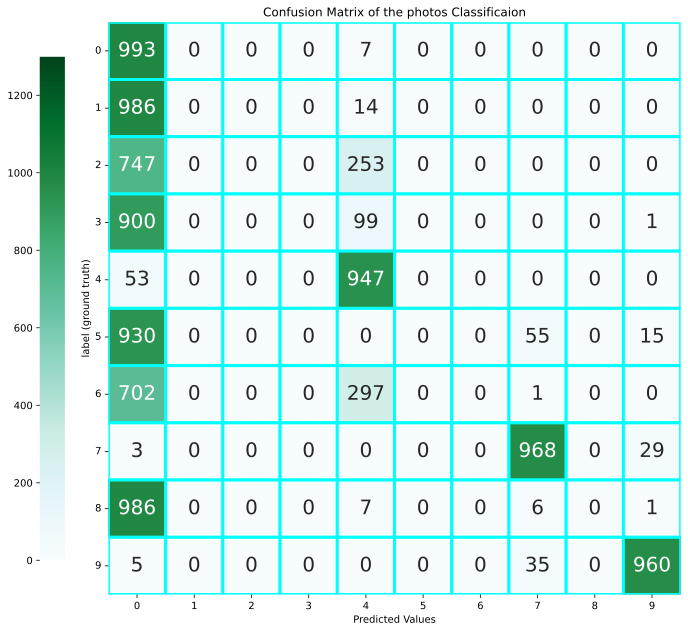

In [185]:
# Display the confusion matrix as a heatmap
arr = confusion_matrix(y_test.view(-1), predicted.view(-1))
df_cm = pd.DataFrame(arr, class_names, class_names)
plt.figure(figsize = (13,13))
#sns.heatmap(df_cm, annot=True, fmt="d", cmap='BuGn')
sns.heatmap(data = df_cm,
            cmap ="BuGn",
            vmin = 0,
            vmax = 1300,
            annot = True,
            annot_kws = {"size":20},
            linewidths = 3,
            linecolor = "cyan",
            xticklabels=list(range(10)),
            yticklabels=list(range(10)),
            square = True,
            fmt ="d",
            cbar_kws = {"shrink" : 0.7 ,
                        "pad" : 0.06  ,
                        "location" : "left" ,
                        "orientation" : "vertical"}
            ).set(
                xlabel = "Predicted Values",
                ylabel = "label (ground truth)",
                title = "Confusion Matrix of the photos Classificaion",
            )
plt.yticks(rotation = 0)

plt.show()

## Great job!